Natasha Abrams - notebook generated via back-and-forth with chatGPT
1-27-26

In [42]:
import numpy as np
import emcee
import corner
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
def sigma_alpha(N, alpha, R):
    """
    Formal propagated uncertainty on power-law slope alpha
    for dN/dM ~ M^-alpha over dynamic range R = Mmax/Mmin.

    Parameters
    ----------
    N : int or float
        Number of stars
    alpha : float
        Power-law slope
    R : float
        Dynamic range Mmax/Mmin

    Returns
    -------
    sigma_alpha : float
        1-sigma uncertainty on alpha
    """

    term = (1.0/(alpha - 1.0)**2
            - (np.log(R)**2 * R**(1.0 - alpha)) /
              (1.0 - R**(1.0 - alpha))**2)

    return 1.0 / np.sqrt(N * term)

In [3]:
def sample_imf(alpha=2.0, m_min=0.08, m_max=100.0, size=1, rng=None):
    """
    Sample stellar masses from a power-law IMF: dN/dM ~ M^-alpha
    """
    if rng is None:
        rng = np.random.default_rng()

    x = rng.random(size)

    if alpha == 1.0:
        # Special logarithmic case
        return m_min * (m_max / m_min) ** x

    b = 1.0 - alpha
    return (x * (m_max**b - m_min**b) + m_min**b) ** (1.0 / b)

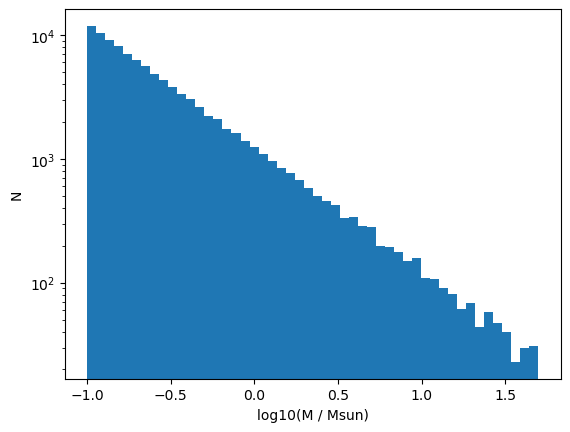

In [5]:
masses = sample_imf(alpha=2.0, m_min=0.1, m_max=50.0, size=100000)

# sanity check
import matplotlib.pyplot as plt
plt.hist(np.log10(masses), bins=50)
plt.xlabel("log10(M / Msun)")
plt.ylabel("N")
plt.yscale('log')
plt.show()

In [10]:
# ---------------------------
# Log-prior
# ---------------------------
def log_prior(theta):
    alpha = theta[0]
    if 1.01 < alpha < 5.0:
        return 0.0
    return -np.inf


# ---------------------------
# Log-likelihood
# ---------------------------
def log_likelihood(theta, masses, m_min, m_max):
    alpha = theta[0]

    if alpha <= 1.0:
        return -np.inf

    N = len(masses)

    norm = (m_min**(1.0-alpha) - m_max**(1.0-alpha))

    if norm <= 0:
        return -np.inf

    term1 = N * np.log(alpha - 1.0)
    term2 = -N * np.log(norm)
    term3 = -alpha * np.sum(np.log(masses))

    return term1 + term2 + term3


# ---------------------------
# Log-posterior
# ---------------------------
def log_probability(theta, masses, m_min, m_max):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, masses, m_min, m_max)

In [11]:
m_min = 0.1
m_max = 50.0

ndim = 1
nwalkers = 32

# initial guess near Salpeter
p0 = 2.0 + 1e-2 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim,
    log_probability,
    args=(masses, m_min, m_max)
)

sampler.run_mcmc(p0, 5000, progress=True)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:36<00:00, 51.80it/s]


State([[2.00254473]
 [1.99940139]
 [2.00182681]
 [2.00178388]
 [2.00168415]
 [2.00136757]
 [2.00918272]
 [2.00129037]
 [2.00880404]
 [2.00852874]
 [2.00121   ]
 [2.00141224]
 [2.00019676]
 [2.00442736]
 [2.00491475]
 [2.00450308]
 [2.0053655 ]
 [2.00704413]
 [2.00468183]
 [2.00748313]
 [2.00735229]
 [1.99896971]
 [2.00310684]
 [2.00526892]
 [2.00087696]
 [2.00498548]
 [1.99695049]
 [2.00544549]
 [1.99901535]
 [2.00582793]
 [2.00179106]
 [2.00578676]], log_prob=[33620.867569   33620.09505336 33620.77127559 33620.76401691
 33620.74649769 33620.68482471 33619.52246528 33620.66838439
 33619.70730066 33619.83349511 33620.65068908 33620.6940852
 33620.37655753 33620.89535913 33620.84962171 33620.88968017
 33620.78797518 33620.39509413 33620.8741924  33620.2499356
 33620.29503492 33619.91781619 33620.9099138  33620.80274908
 33620.57101975 33620.84117849 33618.85994878 33620.77509404
 33619.93736899 33620.7054274  33620.76524177 33620.71356936], blobs=None, random_state=('MT19937', array([171

In [12]:
burnin = 1000
samples = sampler.get_chain(discard=burnin, flat=True)

alpha_samples = samples[:,0]

print("alpha = {:.3f} +/- {:.3f}".format(
    np.mean(alpha_samples),
    np.std(alpha_samples)
))

alpha = 2.004 +/- 0.003


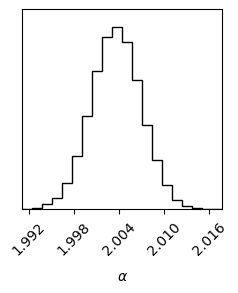

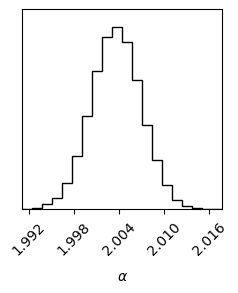

In [14]:
corner.corner(samples, labels=[r"$\alpha$"])

# Try out grid

In [16]:
def fit_alpha_mcmc(masses, m_min, m_max, nsteps=2000):

    ndim = 1
    nwalkers = 32

    p0 = 2.0 + 1e-2 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(
        nwalkers, ndim,
        log_probability,
        args=(masses, m_min, m_max)
    )

    sampler.run_mcmc(p0, nsteps, progress=False)

    samples = sampler.get_chain(discard=500, flat=True)
    alpha_med = np.median(samples[:,0])
    alpha_err = np.std(samples[:,0])

    return alpha_med, alpha_err

In [20]:
true_alphas = [1.8, 2.0, 2.2, 2.4, 2.6]

mass_ranges = [
    (0.1, 10),
    (0.1, 30),
    (0.1, 100),
    (0.5, 30),
    (1.0, 100)
]

Nstars_list = [200, 500, 1000, 5000, 20000]
rng = np.random.default_rng(42)

results = []

print("True_alpha  Mmin  Mmax   Nstars   Recovered_alpha ± sigma")
print("----------------------------------------------------------")

for Nstars in Nstars_list:
    for alpha_true in true_alphas:
        for m_min, m_max in mass_ranges:

            masses = sample_imf(alpha_true, m_min, m_max, Nstars, rng=rng)

            alpha_fit, alpha_err = fit_alpha_mcmc(masses, m_min, m_max)

            results.append([
                Nstars,
                alpha_true,
                m_min,
                m_max,
                alpha_fit,
                alpha_err
            ])

            print(f"{alpha_true:7.2f}  {m_min:4.1f}  {m_max:5.1f}  "
                  f"{Nstars:6d}   {alpha_fit:6.3f} ± {alpha_err:5.3f}")

True_alpha  Mmin  Mmax   Nstars   Recovered_alpha ± sigma
----------------------------------------------------------
   1.80   0.1   10.0     200    1.849 ± 0.073
   1.80   0.1   30.0     200    1.823 ± 0.066
   1.80   0.1  100.0     200    1.801 ± 0.061
   1.80   0.5   30.0     200    1.811 ± 0.077
   1.80   1.0  100.0     200    1.748 ± 0.069
   2.00   0.1   10.0     200    1.936 ± 0.077
   2.00   0.1   30.0     200    2.031 ± 0.078
   2.00   0.1  100.0     200    1.943 ± 0.069
   2.00   0.5   30.0     200    1.920 ± 0.080
   2.00   1.0  100.0     200    1.968 ± 0.079
   2.20   0.1   10.0     200    2.262 ± 0.095
   2.20   0.1   30.0     200    2.251 ± 0.089
   2.20   0.1  100.0     200    2.189 ± 0.085
   2.20   0.5   30.0     200    2.115 ± 0.089
   2.20   1.0  100.0     200    2.261 ± 0.095
   2.40   0.1   10.0     200    2.401 ± 0.102
   2.40   0.1   30.0     200    2.538 ± 0.110
   2.40   0.1  100.0     200    2.272 ± 0.092
   2.40   0.5   30.0     200    2.446 ± 0.108
   2.40  

In [21]:
results = np.array(results)

In [22]:
np.savetxt(
    "imf_mcmc_results.csv",
    results,
    delimiter=",",
    header="Nstars,alpha_true,Mmin,Mmax,alpha_fit,alpha_err",
    comments=""
)

In [4]:
mcmc_results = pd.read_csv("imf_mcmc_results.csv")

In [5]:
mcmc_results

,Nstars,alpha_true,Mmin,Mmax,alpha_fit,alpha_err
0,200.0,1.8,0.1,10.0,1.849201,0.072624
1,200.0,1.8,0.1,30.0,1.822990,0.065894
2,200.0,1.8,0.1,100.0,1.800708,0.061136
3,200.0,1.8,0.5,30.0,1.811222,0.076991
4,200.0,1.8,1.0,100.0,1.747944,0.068522
...,...,...,...,...,...,...
120,20000.0,2.6,0.1,10.0,2.602959,0.011445
121,20000.0,2.6,0.1,30.0,2.591292,0.011277
122,20000.0,2.6,0.1,100.0,2.586741,0.011192
123,20000.0,2.6,0.5,30.0,2.606784,0.011825


In [38]:
# Path to your text file
filename = "weisz_2013_tab1.txt"

# Column names based on the table
colnames = [
    'index',
    "cluster",
    "logN",
    "logMmax_ratio",
    "alpha",
    "sigma",
    "min_mass",
    "max_mass",
    "delta_alpha_ratio",
    "reference"
]

# Read table
df = pd.read_csv(
    filename,
    sep='\t',
    comment="(1)",      # skips Notes section if it starts with N
    skiprows=5,       # skip title + header lines
    skipfooter=1,
    names=colnames,
    engine="python"
)

print(df.head())
print("\nNumber of rows:", len(df))

      index  cluster  logN  logMmax_ratio  alpha  sigma  min_mass  max_mass  \
1  NGC 2323     3.31  0.99           2.94   0.15    0.4       3.9      1.66   
2       M11     3.26  0.49           2.49   0.09    1.1       3.4      0.32   
3   NGC 663     3.15  0.80           2.38   0.22    1.6      10.0      1.54   
4  NGC 2168     3.00  0.78           2.29   0.27    0.6       3.6      1.76   
5  NGC 2422     2.60  0.44           3.07   0.08    0.9       2.5      0.23   

          delta_alpha_ratio  reference  
1     Kalirai et al. (2003)        NaN  
2      Santos et al. (2005)        NaN  
3      Pandey et al. (2005)        NaN  
4     Kalirai et al. (2003)        NaN  
5  Prisinzano et al. (2003)        NaN  

Number of rows: 89


In [39]:
df

,index,cluster,logN,logMmax_ratio,alpha,sigma,min_mass,max_mass,delta_alpha_ratio,reference
1,NGC 2323,3.31,0.99,2.94,0.15,0.4,3.9,1.66,Kalirai et al. (2003),NaN
2,M11,3.26,0.49,2.49,0.09,1.1,3.4,0.32,Santos et al. (2005),NaN
3,NGC 663,3.15,0.80,2.38,0.22,1.6,10.0,1.54,Pandey et al. (2005),NaN
4,NGC 2168,3.00,0.78,2.29,0.27,0.6,3.6,1.76,Kalirai et al. (2003),NaN
5,NGC 2422,2.60,0.44,3.07,0.08,0.9,2.5,0.23,Prisinzano et al. (2003),NaN
...,...,...,...,...,...,...,...,...,...,...
85,NGC 7380,1.04,0.81,2.70,0.30,10.0,65.0,0.51,Massey et al. (1995a),NaN
86,Berkeley86,1.00,0.60,2.70,0.40,10.0,40.0,0.49,Massey et al. (1995a),NaN
87,NGC 2323,0.90,0.20,4.42,1.73,5.0,7.9,1.36,Tarrab (1982),NaN
88,NGC 6913,0.78,0.60,2.10,0.60,10.0,40.0,0.72,Massey et al. (1995a),NaN


In [40]:
mcmc_results

,Nstars,alpha_true,Mmin,Mmax,alpha_fit,alpha_err
0,200.0,1.8,0.1,10.0,1.849201,0.072624
1,200.0,1.8,0.1,30.0,1.822990,0.065894
2,200.0,1.8,0.1,100.0,1.800708,0.061136
3,200.0,1.8,0.5,30.0,1.811222,0.076991
4,200.0,1.8,1.0,100.0,1.747944,0.068522
...,...,...,...,...,...,...
120,20000.0,2.6,0.1,10.0,2.602959,0.011445
121,20000.0,2.6,0.1,30.0,2.591292,0.011277
122,20000.0,2.6,0.1,100.0,2.586741,0.011192
123,20000.0,2.6,0.5,30.0,2.606784,0.011825


In [67]:
sigma_alpha_vals = sigma_alpha(mcmc_results['Nstars'], mcmc_results['alpha_true'], mcmc_results['Mmax']/mcmc_results['Mmin'])

0      0.070641
1      0.064124
2      0.060390
3      0.075460
4      0.070641
         ...   
120    0.011513
121    0.011365
122    0.011325
123    0.011678
124    0.011513
Length: 125, dtype: float64

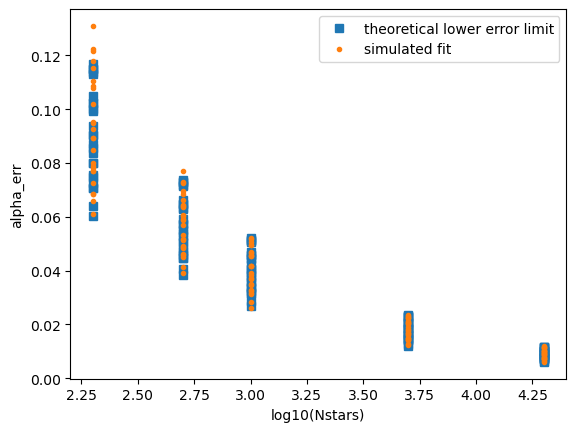

In [81]:
plt.plot(np.log10(mcmc_results['Nstars']), sigma_alpha_vals, marker = 's', linestyle = 'None', label = 'theoretical lower error limit')
plt.plot(np.log10(mcmc_results['Nstars']), mcmc_results['alpha_err'], marker = '.', linestyle = 'None', label = 'simulated fit')
#plt.plot(df['cluster'], df['alpha'], marker = '.', linestyle = 'None', label = 'Weisz 2013 data')
plt.xlabel('log10(Nstars)')
plt.ylabel('alpha_err')
plt.legend()

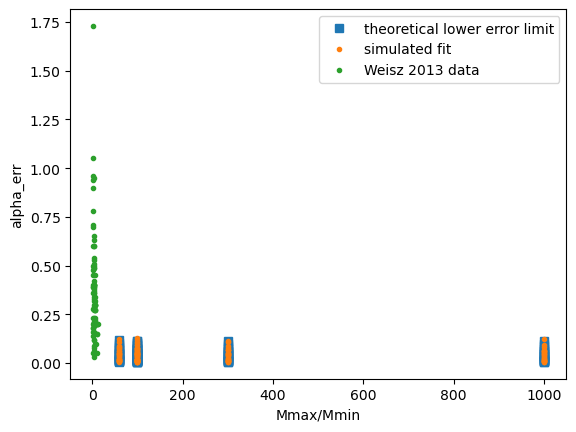

In [73]:
plt.plot(mcmc_results['Mmax']/mcmc_results['Mmin'], sigma_alpha_vals, marker = 's', linestyle = 'None', label = 'theoretical lower error limit')

plt.plot(mcmc_results['Mmax']/mcmc_results['Mmin'], mcmc_results['alpha_err'], marker = '.', linestyle = 'None', label = 'simulated fit')

plt.plot(df['min_mass']/df['sigma'], df['alpha'], marker = '.', linestyle = 'None', label = 'Weisz 2013 data')
plt.xlabel('Mmax/Mmin')
plt.ylabel('alpha_err')
plt.legend()

In [82]:
sigma_alpha_vals_weisz = sigma_alpha(10**df['cluster'], df['logMmax_ratio'], df['min_mass']/df['sigma'])

Text(0, 0.5, 'alpha_err')

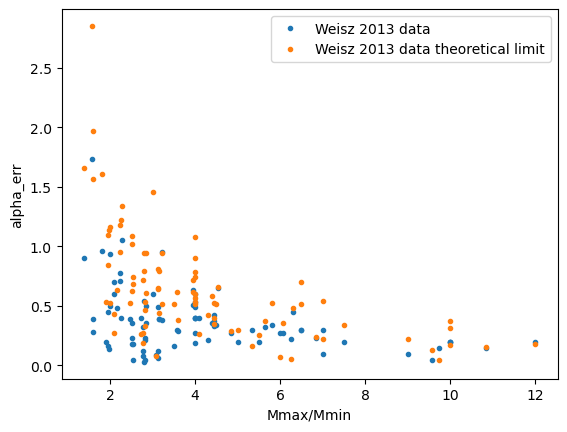

In [83]:
plt.plot(df['min_mass']/df['sigma'], df['alpha'], marker = '.', linestyle = 'None', label = 'Weisz 2013 data')
plt.plot(df['min_mass']/df['sigma'], sigma_alpha_vals_weisz, marker = '.', linestyle = 'None', label = 'Weisz 2013 data theoretical limit')
plt.legend()
plt.xlabel('Mmax/Mmin')
plt.ylabel('alpha_err')

Text(0, 0.5, 'alpha_err')

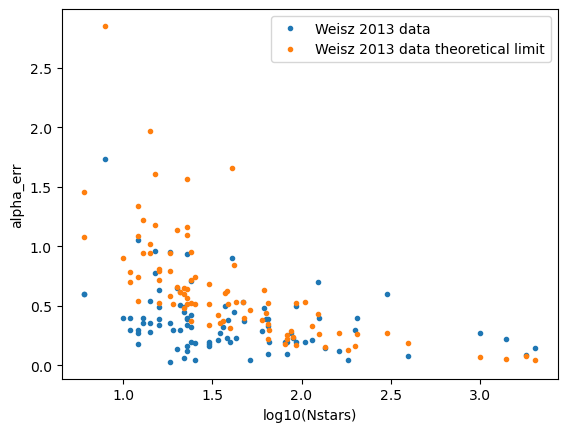

In [84]:
plt.plot(df['cluster'], df['alpha'], marker = '.', linestyle = 'None', label = 'Weisz 2013 data')
plt.plot(df['cluster'], sigma_alpha_vals_weisz, marker = '.', linestyle = 'None', label = 'Weisz 2013 data theoretical limit')
plt.legend()
plt.xlabel('log10(Nstars)')
plt.ylabel('alpha_err')